# Dark Matter Indirect Detection with Gammapy: Basics

Weakly Interacting Massive Particles (WIMPs) are among the most compelling candidates for Dark Matter (DM). If they exist, WIMPs can **annihilate or decay** into Standard Model particles — including gamma rays — that can be detected by gamma-ray instruments such as space-based telescopes (e.g. Fermi-LAT) or ground-based Imaging Atmospheric Cherenkov Telescopes (IACTs) like MAGIC, HESS, VERITAS, or the upcoming CTA Observatory.

The expected gamma-ray flux from a DM source has two independent components:

- **Astrophysical factor (J/D-factor):** encodes the spatial distribution of   DM along the line of sight. It depends on the assumed density profile and the   source distance.

- **Particle physics factor (dN/dE):** encodes the gamma-ray energy spectrum   produced per annihilation or decay event. It depends on the DM mass and the   dominant interaction channel.

The total flux is simply their product:

**Annihilation:**
$$\Phi_{\rm ann}(>E_{\rm min}) = \frac{\langle\sigma v\rangle}{8\pi m_\chi^2} \cdot J \cdot \int_{E_{\rm min}}^{E_{\rm max}} \frac{dN}{dE} \, dE$$

**Decay:**
$$\Phi_{\rm dec}(>E_{\rm min}) = \frac{1}{4\pi \tau_\chi m_\chi} \cdot D \cdot \int_{E_{\rm min}}^{E_{\rm max}} \frac{dN}{dE} \, dE$$

In this tutorial, we cover the building blocks needed to model this signal in Gammapy, using the **Draco dwarf spheroidal galaxy** as our example target — one of the most DM-dominated objects in the local universe and a standard benchmark for indirect detection searches.

The sections of the tutorial are:

- Spatial Distribution
  - Density profiles
  - Astrophysical factor
    - J-Factor
    - D-Factor
- Spectral morphology
  - PPPC4DMID
  - CosmiXs
- Expected gamma-ray flux map

## Setup

In this part we upload all the necessary packages for this tutorials and set up all the data regarding our target source.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u
from astropy.table import Table
from astropy.coordinates import SkyCoord

from gammapy.maps import WcsGeom, WcsNDMap
from gammapy.astro.darkmatter import (
    JFactory,
    PrimaryFlux,
    profiles,
    DarkMatterAnnihilationSpectralModel,
    DarkMatterDecaySpectralModel

)
from regions import CircleSkyRegion

# Source position
position_dwarf_draco = SkyCoord(260.05, 57.915, frame="icrs", unit="deg")

# Distance
distance_dwarf_draco = 76 * u.kpc

## Spatial distribution

To calculate the expected gamma-ray flux from Dark Matter, we first need to understand its spatial distribution. 

For **Dark Matter annihilation**, we use the **J-Factor**. It represents the astrophysical component of the flux and is the integral of the Dark Matter density squared ($\rho^2$) along the line of sight ($l$) integrated over a solid angle ($\Delta \Omega$), since it requires two particles to collide:

$$J = \int_{\Delta \Omega} \int_{l.o.s.} \rho^2(l, \Omega) \, dl \, d\Omega$$

For **Dark Matter decay**, we use the **D-Factor**. This depends linearly on the density ($\rho$), as it involves single particles decaying spontaneously:

$$D = \int_{\Delta \Omega} \int_{l.o.s.} \rho(l, \Omega) \, dl \, d\Omega$$

The calculation procedure in Gammapy is nearly identical for both cases; you only need to toggle a single parameter (`annihilation = True` or `False`) to switch between them.

In this section, we define the spatial parameters for the Draco dwarf spheroidal galaxy, describing the different density profiles availables and how to calculate the astrophysical factors.

### Density profiles

The spatial distribution of Dark Matter within a halo is described by a 
density profile ρ(r). Different theoretical models and observational fits 
predict different shapes, particularly in the inner regions of the halo 
(the so-called "cusp vs core" debate).
The choice of profile is one of the dominant systematic uncertainties 
in DM indirect detection searches.

The current implemented profiles in Gammapy are: Burkert, Einasto, Isothermal, Moore, NFW and Zhao. 	

Each profile is characterized by two scale parameters fitted to observations:

- **r_s (scale radius):** the characteristic distance at which the profile 
  changes slope.

- **ρ_s (scale density):** the overall normalization of the profile, setting 
  the total amount of DM in the halo.

Below you can find a representation of the shape of each available profile.

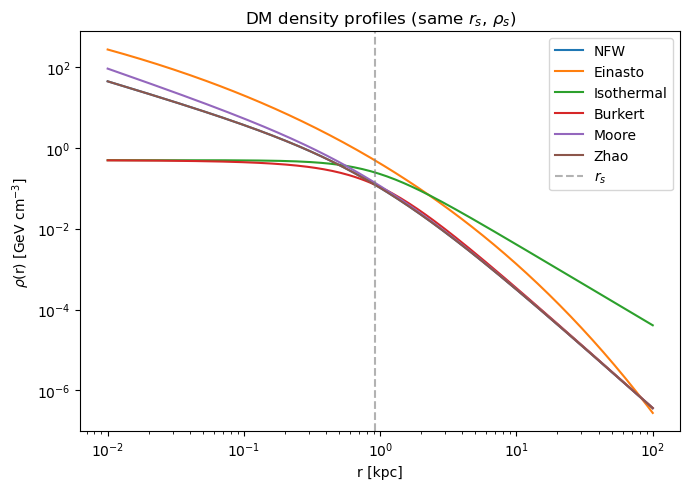

In [3]:
# Common parameters for comparison
r_s = 0.91 * u.kpc # Scale radius
rho_s = 1.3e7 * (u.M_sun / u.kpc**3) # Scale density
rho_s_GeV = rho_s.to(u.GeV / u.cm**3, equivalencies=u.mass_energy()) # Units conversion

# Define radial range for the plot
r = np.logspace(-2, 2, 200) * u.kpc

# Available profiles
profile_list = {
    "NFW"       : profiles.NFWProfile(r_s=r_s, rho_s=rho_s_GeV),
    "Einasto"   : profiles.EinastoProfile(r_s=r_s, rho_s=rho_s_GeV),
    "Isothermal": profiles.IsothermalProfile(r_s=r_s, rho_s=rho_s_GeV),
    "Burkert"   : profiles.BurkertProfile(r_s=r_s, rho_s=rho_s_GeV),
    "Moore"   : profiles.MooreProfile(r_s=r_s, rho_s=rho_s_GeV),
    "Zhao"   : profiles.ZhaoProfile(r_s=r_s, rho_s=rho_s_GeV),

}

fig, ax = plt.subplots(figsize=(7, 5))

for name, profile in profile_list.items():
    rho = profile(r)
    ax.plot(r.value, rho.to("GeV cm-3").value, label=name)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("r [kpc]")
ax.set_ylabel(r"$\rho$(r) [GeV cm$^{-3}$]")
ax.set_title("DM density profiles (same $r_s$, $\\rho_s$)")
ax.axvline(r_s.value, color="gray", linestyle="--", alpha=0.6, label="$r_s$")
ax.legend()
plt.tight_layout()
plt.show()

### Astrophysical factor

Now we are going to calculate the target source J-Factor and D-Factor. For this example we will use an Einasto profile. The steps to follow are:

1. Set a geometry map of the source, acting as a canvas of the sky region we want to study, specifying its center, angular size, and pixel resolution.
2. Compute the JFactor/DFactor using the JFactory class. It is possible to plot the results and also to integrate the factor in a desired region of interest, since not all telescopes have the same angular resolution and Dark Matter halos are extended objects. Additionally, to optimize our observation, we would like to know how much Dark Matter signal is contained within a specific angular radius from the center of the galaxy.

It should be highlighted that the astrophysical factor can be computed with another tools (i.e. CLUMPY) and used within Gammapy, this is just an example if it wants to be calculated within this framework.

In [4]:
# Define the DM profile. Check profiles.DMProfile.__subclasses__() for more profiles
draco_profile = profiles.EinastoProfile(
    r_s=0.91 * u.kpc,       
    rho_s=rho_s_GeV
)

# Geometry map we are going to work with
geom_draco = WcsGeom.create(
    binsz=0.1, # Pixel size
    skydir=position_dwarf_draco, # Sky position of the target, center of the map
    width=3.0, # Width of the map (i.e 3x3 map)          
    frame="icrs" # Coordinates system
)

#### J-Factor

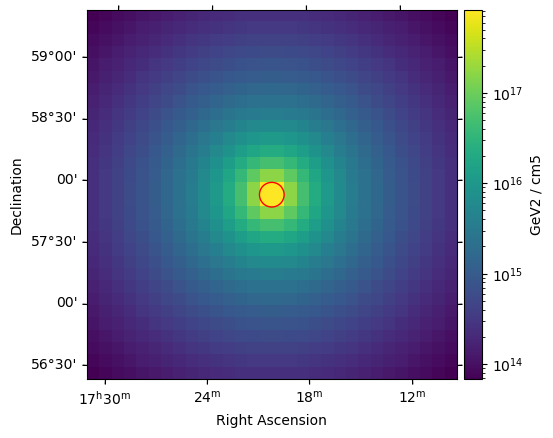

J-factor integrated on 0.1 deg circle (plotted in red): 3.31e+18 GeV2 / cm5


In [5]:
jfactory = JFactory(
    geom=geom_draco, # Geometry map
    profile=draco_profile, # Chosen density profile
    distance=distance_dwarf_draco, # Target distance
    annihilation = True # Set if it is annihilation (true) or decay (false)
)

# Computation of the J factor
jfact_draco = jfactory.compute_jfactor() 

# Map construction for plotting
jfact_map_draco = WcsNDMap(geom=geom_draco, data=jfact_draco.value, unit=jfact_draco.unit)

plt.figure()

ax = jfact_map_draco.plot(cmap="viridis", norm=LogNorm(), add_cbar=True)

# Define a region of interest (i.e., 0.1 deg circle)
sky_reg = CircleSkyRegion(center=position_dwarf_draco, radius=0.1 * u.deg)
pix_reg = sky_reg.to_pixel(wcs=geom_draco.wcs)
pix_reg.plot(ax=ax, facecolor="none", edgecolor="red", label="0.1 deg circle")
plt.show()

# Integration of JFactor within that region
total_jfact = pix_reg.to_mask().multiply(jfact_draco).sum()
print(f"J-factor integrated on 0.1 deg circle (plotted in red): {total_jfact:.3g}")

#### D-Factor

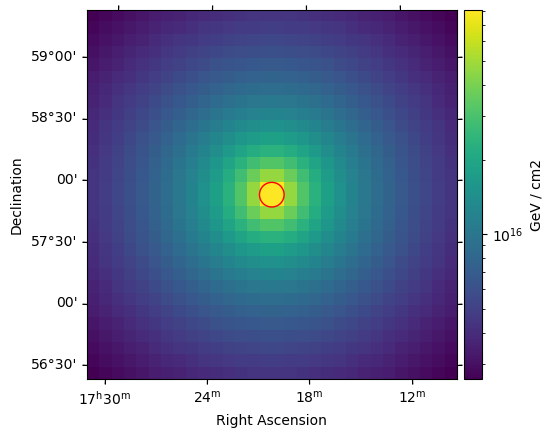

D-factor integrated on 0.1 deg circle (plotted in red): 3.22e+17 GeV / cm2


In [6]:
dfactory = JFactory(
    geom=geom_draco,
    profile=draco_profile,
    distance=distance_dwarf_draco,
    annihilation = False #Set for decay
)

# Compute D factor
dfact_draco = dfactory.compute_jfactor()

# Map construction for plotting
dfact_map_draco = WcsNDMap(geom=geom_draco, data=dfact_draco.value, unit=dfact_draco.unit)

plt.figure()

ax = dfact_map_draco.plot(cmap="viridis", norm=LogNorm(), add_cbar=True)

# Define a region of interest (i.e., 0.1 deg circle)
sky_reg = CircleSkyRegion(center=position_dwarf_draco, radius=0.1 * u.deg)
pix_reg = sky_reg.to_pixel(wcs=geom_draco.wcs)
pix_reg.plot(ax=ax, facecolor="none", edgecolor="red", label="0.1 deg circle")
plt.show()

# Integration of DFactor within that region
total_dfact = pix_reg.to_mask().multiply(dfact_draco).sum()
print(f"D-factor integrated on 0.1 deg circle (plotted in red): {total_dfact:.3g}")

## Spectral distribution

The second component of our model is governed by particle physics. When Weakly Interacting Massive Particles (WIMPs) annihilate (or decay), they produce Standard Model particles that eventually annihilate, decay or hadronize into gamma rays.

The energy spectrum of these gamma rays, dN/dE, depends on two quantities:

- **The DM mass (m_χ):** sets the maximum energy of the photons, since   E_max = m_χ for annihilation (or m_χ/2 for decay).
- **The annihilation/decay channel:** determines the shape of the spectrum.   Different final states (quarks, leptons, gauge bosons) produce different gamma-ray spectra through different annihilation, decay and hadronization chains.

Gammapy implements these spectra via look-up tables from three sources:

- **PPPC4DMID** (Cirelli et al. 2011): tables computed with PYTHIA for a wide   range of masses and channels, including electroweak corrections. This is the standard   reference for most indirect detection analyses.
- **CosmiXs** (Arina et al. 2023): more recent tables with updated Monte Carlo   generators, particularly relevant at high masses (above ~100 TeV) where   PPPC4DMID may be less accurate.
- **Custom file**: a custom spectral table can be provided either as a path to a local file (in any format readable by `astropy.table.Table.read`, e.g. `.ecsv`, `.fits`, `.csv`, `.dat`) or directly as an `astropy.table.Table` object. This table must contain a `mDM` column, a `Log[10,x]` column, and one column per desired channel. If the column names in your file don't match these expected names, a `mapping_dict` must be provided to map them accordingly.

Currently, the default source is PPPC4DMID.

The `PrimaryFlux` class in Gammapy interpolates these tables and returns dN/dE as a spectral model that can be directly combined with the astrohysical factor to compute the expected flux (as shown in the next section).

Here we plot the primary gamma-ray spectrum for a **10 TeV** DM particle annihilating into several typical channels.

> **Important Note:** For the decay, the procedure is the same, but **the mass must be divided by 2**.

> **Note:** Computing these spectra requires the Gammapy datasets to be > downloaded and the `GAMMAPY_DATA` environment variable to be set. > Please follow the instructions at https://docs.gammapy.org/dev/getting-started/index.html#recommended-setup before running the cells below.

In [7]:
#import os
#os.environ["GAMMAPY_DATA"] = "PATH/gammapy-data"

### Example with PPPC4DMID

In this subsection we are going to show the spectra obtained for a mass for different annihilation channels using PPPC4DMID as a source.

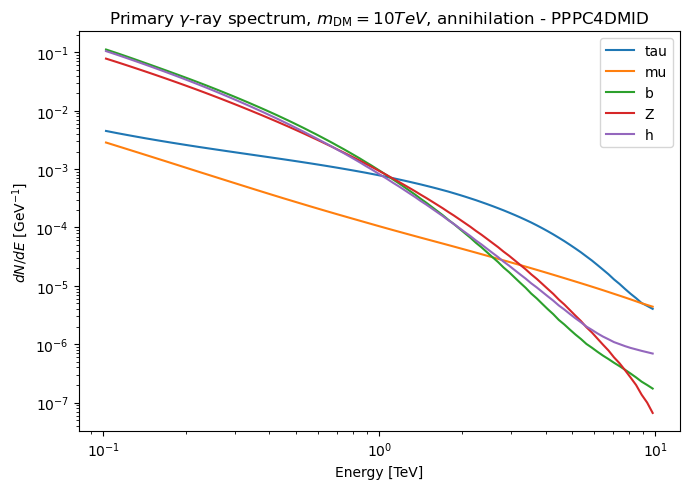

In [8]:
# Define the DM mass and channels of interest
mDM = 10.0 * u.TeV
channels = ["tau", "mu", "b", "Z", "h"]

# To see all available channels: print(PrimaryFlux(mDM=mDM, channel="b").allowed_channels)
fig, ax = plt.subplots(figsize=(7, 5))

for channel in channels:
    fluxes = PrimaryFlux(mDM=mDM, channel=channel)
    fluxes.plot(
        energy_bounds=[mDM / 100, mDM],
        ax=ax,
        label=channel,
        yunits=u.Unit("1/GeV"),
    )

ax.set_yscale("log")
ax.set_xlabel("Energy [TeV]")
ax.set_ylabel(r"$dN/dE$ [GeV$^{-1}$]")
ax.set_title(
    rf"Primary $\gamma$-ray spectrum, $m_{{\rm DM}} = {mDM:.0f}$, annihilation - PPPC4DMID"
)
ax.legend()
plt.tight_layout()
plt.show()

### Example with CosmiXs

To change to CosmiXs source, it must be set into the Primary Flux class with an homonymous parameter.

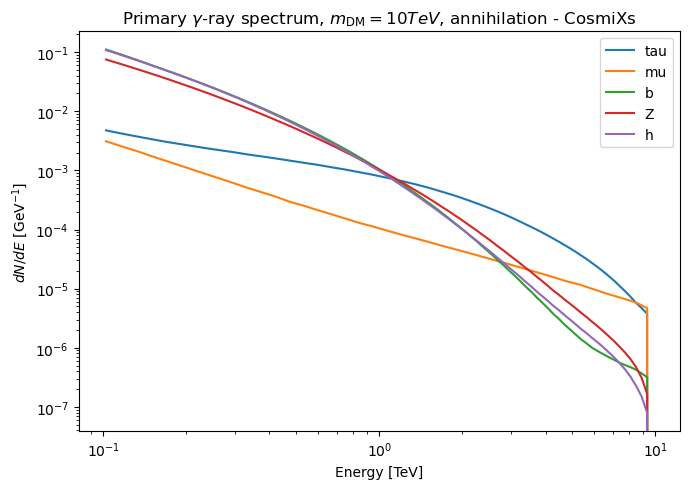

In [9]:
mDM = 10.0 * u.TeV
channels = ["tau", "mu", "b", "Z", "h"]

fig, ax = plt.subplots(figsize=(7, 5))

for channel in channels:
    fluxes = PrimaryFlux(
        mDM=mDM,
        channel=channel,         
        source='cosmixs' # Source parameter
    )
    fluxes.plot(
        energy_bounds=[mDM / 100, mDM],
        ax=ax,
        label=channel,
        yunits=u.Unit("1/GeV")
    )

ax.set_yscale("log")
ax.set_xlabel("Energy [TeV]")
ax.set_ylabel(r"$dN/dE$ [GeV$^{-1}$]")
ax.set_title(
    rf"Primary $\gamma$-ray spectrum, $m_{{\rm DM}} = {mDM:.0f}$, annihilation - CosmiXs"
)
ax.legend()
plt.tight_layout()
plt.show()

### Example with a custom file

To use a custom file source we must  define a path to the file or an astropy.table.Table with the aforementioned format or along with a mapping dictionary.

In [ ]:
# Using the PATH

# Minimal custom spectral table with the expected column names:
# mDM, Log[10,x], and one column per channel
masses = [10, 100, 1000, 10000]  # GeV
log10x = np.linspace(-6, 0, 50)

rows = []
for m in masses:
    for lx in log10x:
        x = 10**lx
        rows.append(
            {
                "mDM": m,
                "Log[10,x]": lx,
                "b": np.exp(-((lx + 1) ** 2)) / x,  # toy dN/dlog10x values
                r"\[Tau]": np.exp(-((lx + 1.5) ** 2)) / x,
            }
        )

custom_table = Table(rows=rows)

# Here by default the table is written in the tutorial container folder, please change the route as you wish
custom_table.write("custom_spectra.ecsv", overwrite=True)
custom_table

mDM,"Log[10,x]",b,\[Tau]
int64,float64,float64,float64
10,-6.0,1.3887943864964022e-05,0.0016052280551856117
10,-5.877551020408164,3.511287822521341e-05,0.00359075937646435
10,-5.755102040816326,8.615321726790191e-05,0.00779493426158445
10,-5.63265306122449,0.00020514132771041162,0.01642158991543198
10,-5.510204081632653,0.0004740360993259886,0.03357333935280614
10,-5.387755102040816,0.0010630318126632651,0.06661169269980317
10,-5.26530612244898,0.002313437117652219,0.12825756527775967
10,-5.142857142857143,0.0048859129936470016,0.23965809614930464
10,-5.020408163265306,0.010014063722332859,0.4345880802393771


<Axes: xlabel='Energy [$\\mathrm{TeV}$]', ylabel='norm [$\\mathrm{GeV^{-1}}$]'>

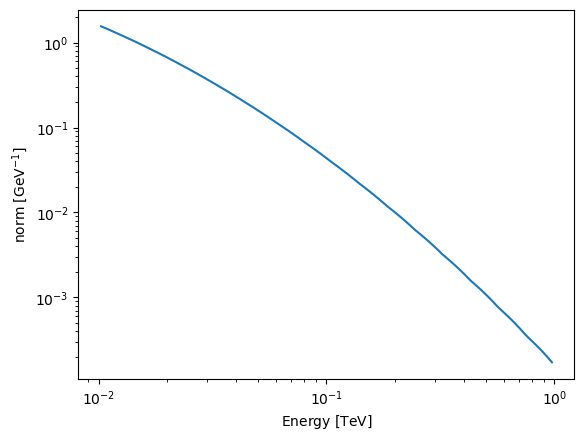

In [18]:
mDM = 1.0 * u.TeV

fluxes_custom = PrimaryFlux(
    mDM=mDM,
    channel="b",
    source="custom_spectra.ecsv",
)
fluxes_custom.plot(energy_bounds=[mDM / 100, mDM], yunits=u.Unit("1/GeV"))

In [ ]:
# Loading the table as an astropy.table.Table object
table = Table.read("custom_spectra.ecsv")
print(table)

fluxes_from_table = PrimaryFlux(mDM=mDM, channel="tau", source=table)

 mDM       Log[10,x]                 b                    \[Tau]       
----- -------------------- ---------------------- ---------------------
   10                 -6.0 1.3887943864964022e-05 0.0016052280551856117
   10   -5.877551020408164  3.511287822521341e-05   0.00359075937646435
   10   -5.755102040816326  8.615321726790191e-05   0.00779493426158445
   10    -5.63265306122449 0.00020514132771041162   0.01642158991543198
   10   -5.510204081632653  0.0004740360993259886   0.03357333935280614
   10   -5.387755102040816  0.0010630318126632651   0.06661169269980317
   10    -5.26530612244898   0.002313437117652219   0.12825756527775967
   10   -5.142857142857143  0.0048859129936470016   0.23965809614930464
   10   -5.020408163265306   0.010014063722332859    0.4345880802393771
   10  -4.8979591836734695   0.019918267666020496    0.7647863146030202
  ...                  ...                    ...                   ...
10000  -1.1020408163265305      12.51753457495884    10.79595194

In [ ]:
# Example of use of mapping dictionary
# Suppose your file follows naming convention instead
# (DM, Log10[x], dNdLog10x[tau], ...)

#fluxes_mapped = PrimaryFlux(
#    mDM=mDM,
#    channel="tau",
#    source="cosmixs_style_table.ecsv",
#    mapping_dict={
#        "DM": "mDM",
#        "Log10[x]": "Log[10,x]",
#        "dNdLog10x[tau]": "\\[Tau]",
#    },
#)

## Expected gamma-ray flux map

Finally, we bring the astrophysical and particle physics components together. The total expected (theoretical) gamma-ray flux from a DM source is the product of the astrophysical factor and the integrated energy spectrum:

**Annihilation:**
$$\Phi_{\rm ann}(>E_{\rm min}) = \frac{\langle\sigma v\rangle}{8\pi m_\chi^2} \cdot J \cdot \int_{E_{\rm min}}^{E_{\rm max}} \frac{dN}{dE} \, dE$$

**Decay:**
$$\Phi_{\rm dec}(>E_{\rm min}) = \frac{1}{4\pi \tau_\chi m_\chi} \cdot D \cdot \int_{E_{\rm min}}^{E_{\rm max}} \frac{dN}{dE} \, dE$$

The maps below show the absolute physical flux arriving at Earth (in cm⁻² s⁻¹), **before** any telescope instrumental effects are applied.
The spatial morphology is entirely determined by the J/D-factor map, while the overall normalization depends on the particle physics model.


`PrimaryFlux` gives you the raw dN/dE table, but it is not yet a model you can plug into Gammapy's modeling/fitting machinery. For that, Gammapy provides two ready-to-use `SpectralModel` classes:

- **`DarkMatterAnnihilationSpectralModel`**
- **`DarkMatterDecaySpectralModel`**

Internally, they wrap `PrimaryFlux` and apply the corresponding normalization (⟨σv⟩/8πm² for annihilation, 1/4πτm for decay) — so you don't need to build the flux formula by hand. Because they are standard `SpectralModel` objects, they expose the same API as any other model in Gammapy (`.evaluate()`, `.integral()`, `.plot()`, combination with a spatial model into a `SkyModel`), which is what makes them directly usable in a full 1D/3D analysis.

In the next section we combine them with the J and D-factor maps computed earlier to get the expected physical flux from Draco.

> **Note on default values:** For `DarkMatterAnnihilationSpectralModel` nor `DarkMatterDecaySpectralModel` Gammapy falls back to conventional benchmark values: $\langle\sigma v\rangle = 3\times10^{-26}\,\mathrm{cm^3\,s^{-1}}$ (the thermal relic cross-section) for annihilation, and $\tau_\chi = 4.3\times10^{17}s $ (age of the Universe) for decay. These are **not** fitted or measured values for Draco — they are illustrative defaults. If you want to fit this parameter, please check the tutorial 'Dark Matter indirect search analysis with Gammapy'.


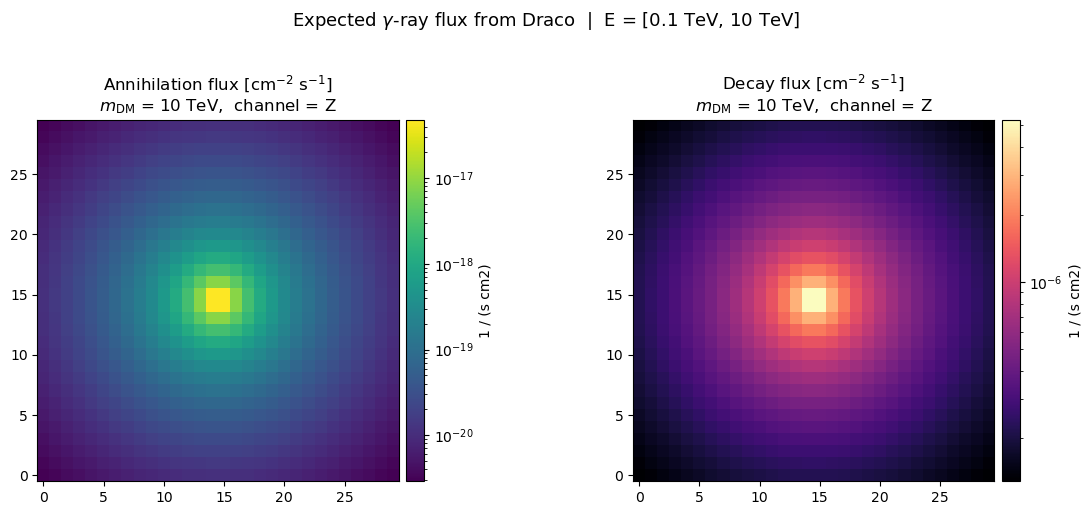

In [ ]:
# Common parameters
channel  = "Z" # Channel
mass_DM  = 10 * u.TeV  # DM mass

# Energy min and max to study
E_min    = 0.1 * u.TeV 
E_max    = mass_DM


# Annihilation flux  (uses J-factor, DarkMatterAnnihilationSpectralModel)

ann_model = DarkMatterAnnihilationSpectralModel(
    mass=mass_DM, 
    channel=channel,
    #source = 'cosmixs' # Here the source is also a parameter, since this class wraps Primary flux.
    )

int_flux_ann = (
    jfact_draco * ann_model.integral(energy_min=E_min, energy_max=E_max)
).to("cm-2 s-1")


# Decay flux (uses D-factor, DarkMatterDecaySpectralModel)
# For the D-factor we recompute JFactory with annihilation=False

jfactory_dec = JFactory(
    geom=geom_draco,
    profile=draco_profile,
    distance=distance_dwarf_draco,
    annihilation=False,
)
dfact_draco = jfactory_dec.compute_jfactor()

dec_model = DarkMatterDecaySpectralModel(
    mass=mass_DM, 
    channel=channel
    )

int_flux_dec = (
    dfact_draco * dec_model.integral(energy_min=E_min, energy_max=E_max)
).to("cm-2 s-1")


# Plot side by side

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Annihilation ---
flux_map_ann = WcsNDMap(
    geom=geom_draco, data=int_flux_ann.value, unit="cm-2 s-1"
)
flux_map_ann.plot(
    ax=axes[0],
    cmap="viridis",
    norm=LogNorm(),
    add_cbar=True,
)
axes[0].set_title(
    f"Annihilation flux [cm$^{{-2}}$ s$^{{-1}}$]\n"
    f"$m_{{\\rm DM}}$ = {mass_DM:.0f},  channel = {channel}"
)

# --- Decay ---
flux_map_dec = WcsNDMap(
    geom=geom_draco, data=int_flux_dec.value, unit="cm-2 s-1"
)
flux_map_dec.plot(
    ax=axes[1],
    cmap="magma",
    norm=LogNorm(),
    add_cbar=True,
)
axes[1].set_title(
    f"Decay flux [cm$^{{-2}}$ s$^{{-1}}$]\n"
    f"$m_{{\\rm DM}}$ = {mass_DM:.0f},  channel = {channel}"
)

plt.suptitle(
    f"Expected $\\gamma$-ray flux from Draco  |  "
    f"E = [{E_min:.1f}, {E_max:.0f}]",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

## References

- Arina, C. et al. 2023, *JCAP*, 05, 024 — CosmiXs: Cosmic messenger spectra for indirect dark matter searches. [arXiv:2312.01153](https://arxiv.org/abs/2312.01153)
- Bergström, L., Ullio, P., & Buckley, J.H. 1998, Astroparticle Physics, 9, 137–162. - Observability of gamma rays from dark matter neutralino annihilations in the Milky Way halo. [astro-ph/9712318](https://arxiv.org/abs/astro-ph/9712318)
- Bonnivard, V. et al. 2015,*MNRAS*, 453, 849 — Dark matter annihilation and decay in dwarf spheroidal galaxies: The classical and ultrafaint dSphs. [arXiv:1504.02048](https://arxiv.org/abs/1504.02048)
- Cirelli, M. et al. 2011, *JCAP*, 03, 051 — PPPC 4 DM ID: A Poor Particle Physicist Cookbook for Dark Matter Indirect Detection. [arXiv:1012.4515](https://arxiv.org/abs/1012.4515)
